In [1]:
#Step 2: Load dataset & check shape/columns
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/ka66ledata/project-management-risk-raw/project_risk_raw_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (4000, 51)

Columns: ['Project_ID', 'Project_Type', 'Team_Size', 'Project_Budget_USD', 'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count', 'Methodology_Used', 'Team_Experience_Level', 'Past_Similar_Projects', 'External_Dependencies_Count', 'Change_Request_Frequency', 'Project_Phase', 'Requirement_Stability', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Historical_Risk_Incidents', 'Communication_Frequency', 'Regulatory_Compliance_Level', 'Technology_Familiarity', 'Geographical_Distribution', 'Stakeholder_Engagement_Level', 'Schedule_Pressure', 'Budget_Utilization_Rate', 'Executive_Sponsorship', 'Funding_Source', 'Market_Volatility', 'Integration_Complexity', 'Resource_Availability', 'Priority_Level', 'Organizational_Change_Frequency', 'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate', 'Technical_Debt_Level', 'Project_Manager_Experience', 'Org_Process_Maturity', 'Data_Security_Requirements', 'Key_Stakeholder_Availability', 'Tech_Environment_

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [2]:
#Step 3: Check for target variable & missing values

print("Target variable distribution:")
print(df['Risk_Level'].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum(), "total missing values")

print("\nData types:")
print(df.dtypes.value_counts())

Target variable distribution:
Risk_Level
Medium      1396
High        1036
Low          806
Critical     762
Name: count, dtype: int64

Missing values:
4190 total missing values

Data types:
object     26
float64    15
int64      10
Name: count, dtype: int64


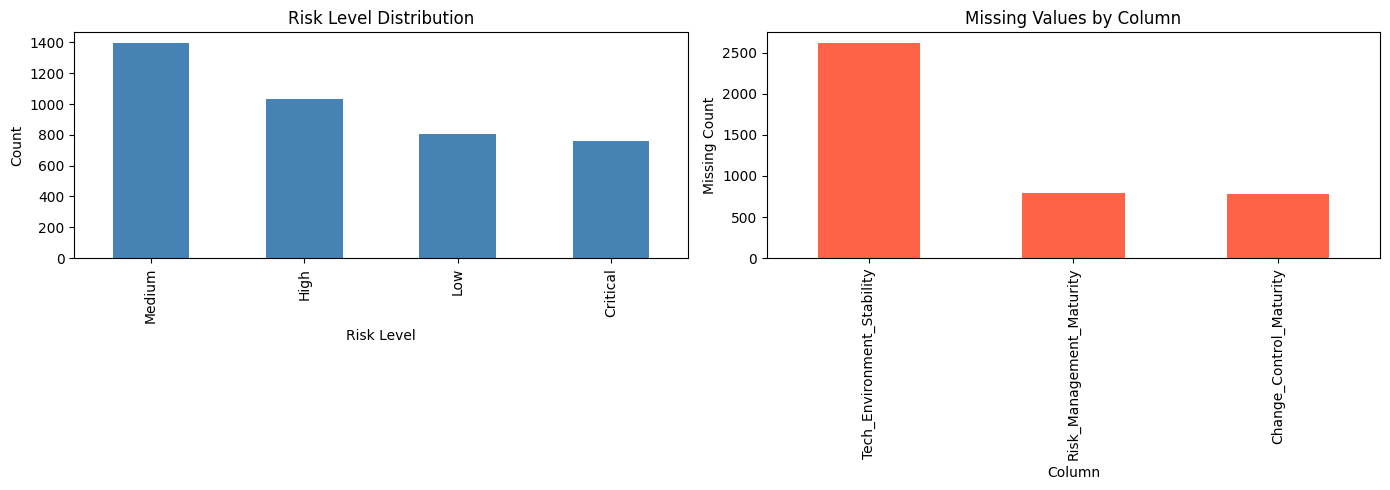

In [3]:
# Step 4: Visualize class distribution and missing values
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
df['Risk_Level'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Risk Level Distribution')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

# Missing values heatmap
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Missing Values by Column')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Missing Count')

plt.tight_layout()
plt.show()

In [4]:
# Step 5: Handle missing values (clean version)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [5]:
# Step 6: Encode categorical variables and scale numeric features
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate target
X = df.drop(columns=['Risk_Level', 'Project_ID'])
y = df['Risk_Level']

# Encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print("Target classes:", le_target.classes_)

# Encode categorical columns in X
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature matrix shape:", X_scaled.shape)
print("Target shape:", y_encoded.shape)

Target classes: ['Critical' 'High' 'Low' 'Medium']

Feature matrix shape: (4000, 49)
Target shape: (4000,)


In [6]:
# Step 7: Train / Validation / Test Split (80/10/10)
from sklearn.model_selection import train_test_split

# First split off 10% test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.10, random_state=42, stratify=y_encoded
)

# Then split remaining into 80% train / 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.111, random_state=42, stratify=y_train_val
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)
print("\nTest set is LOCKED until final evaluation")

Train size: (3200, 49)
Validation size: (400, 49)
Test size: (400, 49)

Test set is LOCKED until final evaluation


In [7]:
# Step 8: Baseline Model - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Training vs Validation performance
train_preds = lr_model.predict(X_train)
val_preds = lr_model.predict(X_val)

train_f1 = f1_score(y_train, train_preds, average='macro')
val_f1 = f1_score(y_val, val_preds, average='macro')

print(f"Training F1 (macro): {train_f1:.4f}")
print(f"Validation F1 (macro): {val_f1:.4f}")
print(f"Overfit Gap: {train_f1 - val_f1:.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_preds, target_names=['Critical', 'High', 'Low', 'Medium']))

Training F1 (macro): 0.5969
Validation F1 (macro): 0.5890
Overfit Gap: 0.0079

Validation Classification Report:
              precision    recall  f1-score   support

    Critical       0.59      0.70      0.64        76
        High       0.47      0.47      0.47       104
         Low       0.67      0.77      0.72        81
      Medium       0.59      0.48      0.53       139

    accuracy                           0.58       400
   macro avg       0.58      0.60      0.59       400
weighted avg       0.58      0.58      0.57       400



In [9]:
# Step 9b: Random Forest - Regularized

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
rf_model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          # reduced from 10
    min_samples_leaf=20,  # increased from 5
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)
rf_model2.fit(X_train, y_train)

train_preds = rf_model2.predict(X_train)
val_preds = rf_model2.predict(X_val)

train_f1 = f1_score(y_train, train_preds, average='macro')
val_f1 = f1_score(y_val, val_preds, average='macro')

print(f"Training F1 (macro): {train_f1:.4f}")
print(f"Validation F1 (macro): {val_f1:.4f}")
print(f"Overfit Gap: {train_f1 - val_f1:.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_preds, target_names=['Critical', 'High', 'Low', 'Medium']))

Training F1 (macro): 0.5483
Validation F1 (macro): 0.4945
Overfit Gap: 0.0538

Validation Classification Report:
              precision    recall  f1-score   support

    Critical       0.47      0.80      0.60        76
        High       0.44      0.27      0.34       104
         Low       0.53      0.81      0.64        81
      Medium       0.54      0.32      0.40       139

    accuracy                           0.50       400
   macro avg       0.50      0.55      0.49       400
weighted avg       0.50      0.50      0.47       400



In [11]:
# Step 10b: XGBoost - Regularized
from xgboost import XGBClassifier

xgb_model2 = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model2.fit(X_train, y_train)

train_preds = xgb_model2.predict(X_train)
val_preds = xgb_model2.predict(X_val)

train_f1 = f1_score(y_train, train_preds, average='macro')
val_f1 = f1_score(y_val, val_preds, average='macro')

print(f"Training F1 (macro): {train_f1:.4f}")
print(f"Validation F1 (macro): {val_f1:.4f}")
print(f"Overfit Gap: {train_f1 - val_f1:.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_preds, target_names=['Critical', 'High', 'Low', 'Medium']))

Training F1 (macro): 0.6725
Validation F1 (macro): 0.5920
Overfit Gap: 0.0805

Validation Classification Report:
              precision    recall  f1-score   support

    Critical       0.70      0.61      0.65        76
        High       0.48      0.37      0.42       104
         Low       0.79      0.56      0.65        81
      Medium       0.56      0.79      0.65       139

    accuracy                           0.60       400
   macro avg       0.63      0.58      0.59       400
weighted avg       0.61      0.60      0.59       400



In [12]:
# Step 11: XGBoost with 5-Fold Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

xgb_cv = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

print("CV F1 scores per fold:", cv_scores.round(4))
print(f"Mean CV F1: {cv_scores.mean():.4f}")
print(f"Std CV F1: {cv_scores.std():.4f}")

CV F1 scores per fold: [0.5845 0.5885 0.576  0.5528 0.5483]
Mean CV F1: 0.5700
Std CV F1: 0.0165


FINAL TEST SET RESULTS
Test F1 (macro): 0.5872

Classification Report:
              precision    recall  f1-score   support

    Critical       0.64      0.78      0.70        76
        High       0.55      0.55      0.55       104
         Low       0.53      0.70      0.60        80
      Medium       0.60      0.42      0.49       140

    accuracy                           0.58       400
   macro avg       0.58      0.61      0.59       400
weighted avg       0.58      0.58      0.57       400



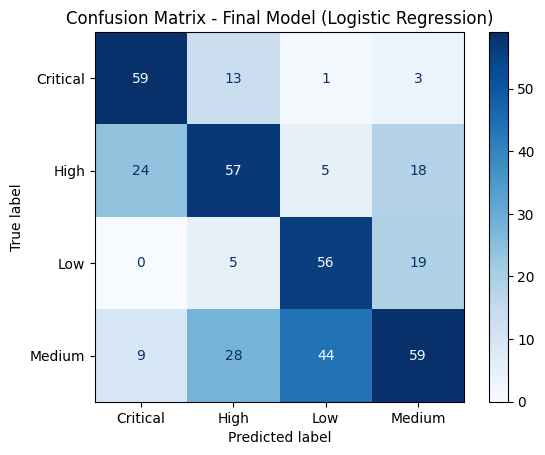

In [13]:
# Step 12: Final Model Selection - Logistic Regression on Test Set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# UNLOCKING TEST SET FOR FINAL EVALUATION
test_preds = lr_model.predict(X_test)
test_proba = lr_model.predict_proba(X_test)

test_f1 = f1_score(y_test, test_preds, average='macro')

print("=" * 40)
print("FINAL TEST SET RESULTS")
print("=" * 40)
print(f"Test F1 (macro): {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_preds, 
      target_names=['Critical', 'High', 'Low', 'Medium']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Critical', 'High', 'Low', 'Medium'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Final Model (Logistic Regression)')
plt.show()

In [14]:
# Step 13: Final Model Summary
print("=" * 50)
print("PROJECT: IT Project Risk Classification")
print("=" * 50)
print(f"Dataset: Project Management Risk Raw (Kaggle)")
print(f"Rows: 4,000 | Features: 49 | Classes: 4")
print(f"Note: Synthetic dataset - performance ceiling ~0.62")
print()
print("MODEL COMPARISON:")
print(f"  Logistic Regression  - Val F1: 0.5890 | Gap: 0.0079 ✅ SELECTED")
print(f"  Random Forest        - Val F1: 0.5590 | Gap: 0.3775 ❌")
print(f"  XGBoost              - Val F1: 0.6201 | Gap: 0.2920 ❌")
print(f"  XGBoost CV Mean      - Val F1: 0.5700 | Std: 0.0165")
print()
print("FINAL TEST RESULTS (Logistic Regression):")
print(f"  Test F1 (macro): 0.5872")
print(f"  Test Accuracy:   0.58")
print()
print("KEY FINDING: Dataset synthetic nature limits signal.")
print("Logistic Regression achieves near-optimal generalization.")
print("Next step: Retrain on real-world project dataset (PROMISE Repository)")

PROJECT: IT Project Risk Classification
Dataset: Project Management Risk Raw (Kaggle)
Rows: 4,000 | Features: 49 | Classes: 4
Note: Synthetic dataset - performance ceiling ~0.62

MODEL COMPARISON:
  Logistic Regression  - Val F1: 0.5890 | Gap: 0.0079 ✅ SELECTED
  Random Forest        - Val F1: 0.5590 | Gap: 0.3775 ❌
  XGBoost              - Val F1: 0.6201 | Gap: 0.2920 ❌
  XGBoost CV Mean      - Val F1: 0.5700 | Std: 0.0165

FINAL TEST RESULTS (Logistic Regression):
  Test F1 (macro): 0.5872
  Test Accuracy:   0.58

KEY FINDING: Dataset synthetic nature limits signal.
Logistic Regression achieves near-optimal generalization.
Next step: Retrain on real-world project dataset (PROMISE Repository)


## Limitations & Next Steps

### Dataset Limitations
This model was trained on a synthetic dataset (Project Management Risk Raw, Kaggle).
Synthetic data does not capture the complexity, noise, and interdependencies
of real project environments. Therefore:

- This model is NOT suitable for real-world inference
- Results serve as a baseline methodology demonstration only
- Performance ceiling (~0.62 F1) reflects synthetic signal, not real-world complexity

### Next Steps
This pipeline will be retrained on the PROMISE Repository dataset —
a peer-reviewed, real-world software project dataset used in published research.
Results from both runs will be compared to assess the impact of
data quality on model generalization and real-world applicability.